# Assignment 2 – Zero-Shot Image Classification with Transformers

In this assignment, you will apply a pre-trained vision–language transformer (e.g. CLIP) to perform **zero-shot** classification on the Fashion-MNIST dataset—classifying each image without any task-specific training. You will build on the concepts from Assignment 1 by comparing this “off-the-shelf” approach to the CNN you previously trained.

You will:
1. **Load** the Fashion-MNIST images using PyTorch instead of Keras.
2. **Run a zero-shot baseline** with simple text prompts to set a performance reference.
3. **Engineer improved prompts** and measure the resulting accuracy gains.
4. **Visualise image embeddings** with UMAP to inspect class separability.
5. **Conduct one mini-experiment** of your choice.
6. **Summarise findings** and reflect on strengths and weaknesses of zero-shot transformers versus a trained CNN.

# 1. Loading the Fashion-MNIST Dataset

As in assignment 1, we'll load the Fashion-MNIST dataset, but this time using `torchvision.datasets` to ensure compatibility with the `transformers` library. We will also load our model and processor from the `transformers` library.

The transformers library allows us to use pre-trained models like CLIP, which can perform zero-shot classification by leveraging the text prompts we provide. There are two key objects we will use: the `CLIPModel` for the model itself and the `CLIPProcessor` for preparing our images and text prompts.

Since we are not actually training a model in this assignment, we will set the CLIP model to evaluation mode. If the model is designed to utilize features like dropout or batch normalization, setting it to evaluation mode ensures that these features behave correctly during inference (prediction). Setting the model to evaluaton mode also tells PyTorch that we don't have to compute gradients, which can save memory and speed up inference.

In order to speed up processing, we will also move the model to an "accelerator" if available. This is typically a GPU, but modern MacBooks also have an "Apple Silicon" accelerator that can be used for inference, called MPS (Metal Performance Shaders). If you are using a MacBook with Apple Silicon, you can use the MPS device for faster processing.

In [2]:
# Uncomment and run if required
#!pip install transformers torchvision torch accelerate

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.datasets import fetch_openml
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import seaborn as sns
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")


In [7]:
from transformers import CLIPModel, CLIPProcessor
import torch

clip_model_name = "openai/clip-vit-base-patch32"
clip_model     = CLIPModel.from_pretrained(clip_model_name)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name, use_fast=False)

# Set model to evaluation mode, as we are not training it
clip_model.eval()

# Check for accelerators
device = "cpu" # Default to CPU
if torch.cuda.is_available():
    device = "cuda" # Use GPU if available
elif torch.backends.mps.is_available():
    device = "mps"

clip_model.to(device)

print(f"Using device: {device}")

Using device: cpu


Now we are ready to load the testing set from Fashion-MNIST. We will use the `torchvision.datasets.FashionMNIST` class to load the dataset. We do not need to apply any transformations to the images, as the `CLIPProcessor` ensures any input images are in the format that the model is trained on.

You should:

- [ ] Use the `torchvision.datasets.FashionMNIST` class to load the *test* split of the dataset. Documentation is available [here](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html).
- [ ] Create a PyTorch `DataLoader` to iterate over the dataset in batches. Use a batch size of 16 and set `shuffle=True` to randomise the order of the images. You will also need to supply the provided `collate_clip` function to the `DataLoader collate_fn` argument to ensure the images are processed correctly. Documentation for `DataLoader` is available [here](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).

In [8]:
from torchvision import datasets
from torch.utils.data import DataLoader

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

def collate_clip(batch):
    imgs, labels = zip(*batch) # Unzip the batch into images and labels
    proc = clip_processor(images=list(imgs),
                        return_tensors="pt",
                        padding=True) # Process images with CLIPProcessor
    # Send pixel_values to GPU/CPU now; labels stay on CPU for metrics
    return proc["pixel_values"].to(device), torch.tensor(labels)


#test_dataset = # Complete
test_dataset = datasets.FashionMNIST(root="./data",train=False,download=True)

#test_loader = # Complete
test_loader = DataLoader(test_dataset,batch_size=16,shuffle=True,collate_fn=collate_clip)


If your code is correct, the following cell should show the first batch of images from the Fashion-MNIST dataset:

Unused or unrecognized kwargs: padding.


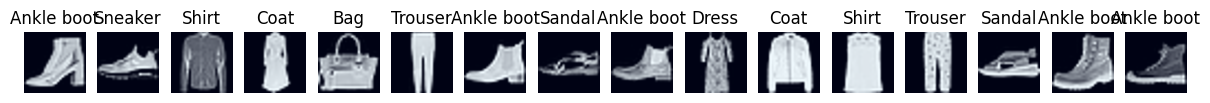

In [62]:
import matplotlib.pyplot as plt

# Display the first batch of images from `test_loader`

def show_batch(loader):
    images, labels = next(iter(loader))
    images = images.cpu()  # Move images to CPU for plotting
    # Renormalize to [0, 1] for visualization
    images = (images - images.min()) / (images.max() - images.min())
    _, axes = plt.subplots(1, len(images), figsize=(15, 5))
    for ax, img, label in zip(axes, images, labels):
        ax.imshow(img.permute(1, 2, 0))
        ax.set_title(CLASS_NAMES[label.item()])
        ax.axis('off')
    plt.show()

show_batch(test_loader)

We’re now ready to run our zero-shot classification baseline!

# Brief Introduction to Zero-Shot Classification

In Assignment 1, we followed the typical machine-learning pipeline: we trained a CNN on the Fashion-MNIST dataset, using labelled examples to update the model’s weights. While effective, that approach requires a curated, task-specific training set—a luxury you don’t always have in practice.

Zero-shot classification flips the script.  A large vision–language model (VLM) such as **CLIP** is first pre-trained on hundreds of millions of image–text pairs scraped from the web.  Because it learns *joint* visual–textual embeddings, the model can later solve new tasks simply by “measuring” how similar an image is to a **text prompt** that describes each candidate class—without seeing a single task-labelled example.

**How it works**  
1. Feed an image through CLIP’s vision encoder → **image feature**.  
2. Feed a textual prompt (e.g. “a photo of a sandal”) through CLIP’s text encoder → **text feature**.  
3. Compute cosine similarity between the image feature and every class’s text feature.  
4. Pick the class whose prompt is most similar.

For our first attempt, we’ll use the bare class names as prompts, e.g.:

- "T-shirt/top"
- "Trouser"

### You should:

- [ ] Build embeddings: use the `get_text_embeddings` helper function to create text embeddings for the class names.
- [ ] Run inference: use the `get_image_embeddings` helper function to create image embeddings.
- [ ] Compute cosine similarity: complete and use the `get_cosine_similarity` helper function to compute the cosine similarity between the image and text embeddings.
- [ ] Make predictions: use the `get_predictions` helper function to get the predicted class for each image in the batch.

Note that for normalized vectors like the ones we are using, cosine similarity is equivalent to the dot product. This means we can use the handy formula `cosine_similarity = vector_a @ vector_b.T` to compute the similarity between the image and text embeddings.

In [63]:
##Text Embeddings

def get_text_embeddings(class_names: list[str]) -> torch.Tensor:
    """    Get text embeddings for the given class names using CLIP.
    Args:
        class_names (list[str]): List of class names to encode.
    Returns:
        torch.Tensor: Normalized text embeddings for the class names.
    """
    tokenized = clip_processor(text=class_names,
                               padding=True,
                               return_tensors="pt").to(device)
    
    with torch.no_grad():
        text_embeddings = clip_model.get_text_features(**tokenized)
        
    text_feats = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)

    return text_feats

#Image Embeddings
def get_image_embeddings(images: torch.Tensor) -> torch.Tensor:
    """    Get image embeddings for the given images using CLIP.
    Args:
        images (torch.Tensor): Batch of images to encode.
    Returns:
        torch.Tensor: Normalized image embeddings for the images.
    """
    with torch.no_grad():
        image_embeddings = clip_model.get_image_features(pixel_values=images)

    image_feats = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)

    return image_feats

In [64]:
import numpy as np

#Cosine Similarity

def get_cosine_similarity(image_feats: torch.Tensor, text_feats: torch.Tensor) -> np.ndarray:
    """
    Compute cosine similarity between image features and text features.
    Args:
        image_feats (torch.Tensor): Image features of shape (N, D).
        text_feats (torch.Tensor): Text features of shape (M, D).
    Returns:
        numpy.ndarray: Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    """
    image_feats = image_feats.cpu()  # image features are on CPU
    text_feats = text_feats.cpu()    #  text features are on CPU

    # Compute cosine similarity, which is the dot product of normalized vectors
    similarity = image_feats @ text_feats.T

    return similarity.numpy()# Complete

def get_predictions(similarity: np.ndarray) -> np.ndarray:
    """
    Get predictions based on cosine similarity scores.
    Args:
        similarity (numpy.ndarray): Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    Returns:
        numpy.ndarray: Predicted class indices for each image, shape (N,).
    """
    # Get the index of the maximum similarity for each image
    return  np.argmax(similarity, axis=1) # Complete

With these functions complete, you are ready to run the zero-shot classification baseline. Complete the code to follow these steps:

- [ ] Build text embeddings for the class names using the `get_text_embeddings` function (this only needs to be done once).
- [ ] For each batch of images:
    - [ ] Get image embeddings using the `get_image_embeddings` function.
    - [ ] Compute cosine similarity between the image and text embeddings using the `get_cosine_similarity` function.
    - [ ] Save the predictions so that we can build a confusion matrix later.
- [ ] Report the accuracy of the predictions and the confusion matrix using the `accuracy_score` and `confusion_matrix` functions from `sklearn.metrics`.

In [65]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Create text embeddings 
text_feats = get_text_embeddings(CLASS_NAMES)

y_true, y_pred = [], []
for pixel_values, labels in test_loader:

# Report the accuracy of the predictions
    image_feats = get_image_embeddings(pixel_values) 
    similarity = get_cosine_similarity(image_feats, text_feats) #Compare images to class 
    pred = get_predictions(similarity)  #class with highest similarity score
    y_true.extend(labels.numpy())
    y_pred.extend(pred)
accuracy = accuracy_score(y_true, y_pred)
print("Baseline Zero-Shot Accuracy:", accuracy) 

Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.


Baseline Zero-Shot Accuracy: 0.624


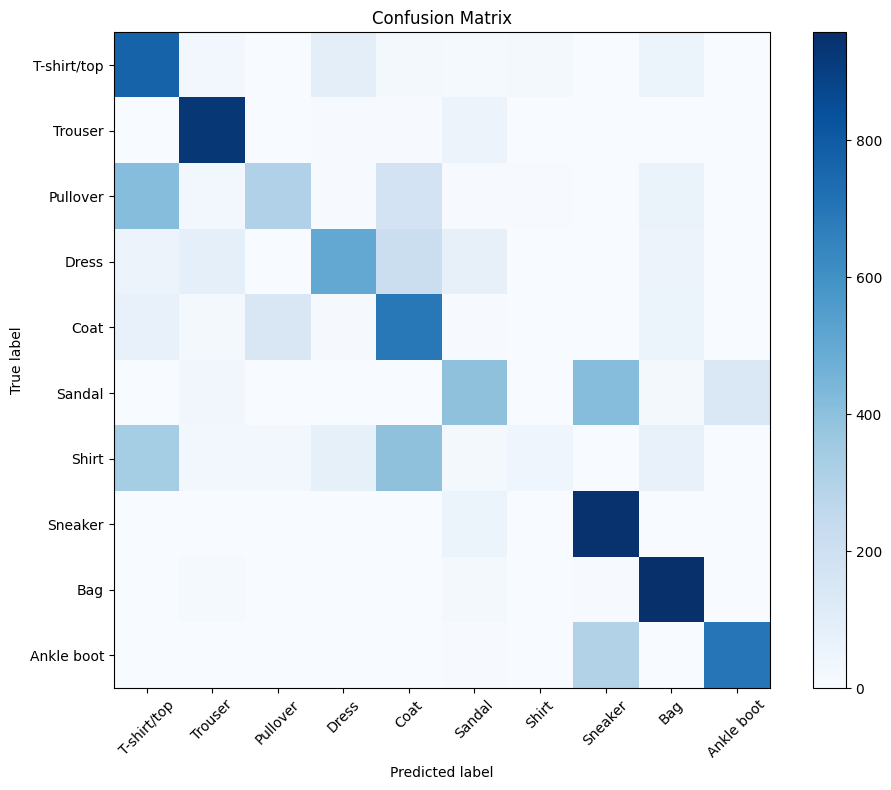

In [66]:
# Report the confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_true, y_pred, CLASS_NAMES)


Reflection: Consider the results. How does the performance of this zero-shot baseline compare to the CNN you trained in Assignment 1? What are the strengths and weaknesses of this approach?

Answer: 
The CNN performs  Assgnment-1 better accuracy 90 % because it is trained for this exact task, 
while CLIP’s zero-shot approach is more flexible and data-efficient but less 
accurate on small, specialized datasets like Fashion-MNIS.
The baseline zero-shot approach achieved an accuracy of 62.4%.

Key factors:
Strengths of Zero-Shot (CLIP): It requires zero labeled training data, saves immense amounts of training 
time, and is highly flexible—you can add or change target classes just by editing the text prompts.
    
Weaknesses of Zero-Shot (CLIP):
It struggles with the "domain gap" (CLIP expects high-resolution color web photos, not tiny, 
low-resolution grayscale images), has a hard time distinguishing between semantically
overlapping words (like "Shirt" vs. "T-shirt"), and is far more computationally heavy during inference 
than a simple custom CNN.

## Improving Zero-Shot Classification with Prompt Engineering

In the previous section, we directly used the class names as text prompts for zero-shot classification. However, we can often improve performance by crafting more descriptive prompts that better capture the visual characteristics of each class. For example, instead of just "T-shirt/top", we could use "a photo of a T-shirt" or "a photo of a top". This additional context can help the model make more accurate predictions.

In this section, we will experiment with more detailed prompts for each class to see if we can improve the zero-shot classification performance. You should:

- [ ] Create a list of improved prompts for each class. For example, instead of just "T-shirt/top", you could use "a photo of a T-shirt" or "a photo of a top".
- [ ] Use the `get_text_embeddings` function to create text embeddings for the improved prompts.
- [ ] Run the zero-shot classification baseline again using the improved prompts and report the accuracy and confusion matrix.

Note: Take advantage of the confusion matrix above. If two classes are often confused, consider how you might improve the prompts to help the model distinguish them better.

The aim for this section is for you to improve the performance of the model. However, if you find that the performance does not improve significantly, you can still reflect on the process and consider how you might further refine the prompts with more effort.

Reflection: How did your detailed prompts affect the zero-shot classification performance? Did you see a significant improvement compared to the baseline? What insights did you gain about the model's understanding of the classes? Do you think that with more effort you could further improve the performance? If so, how?

In [67]:
IMPROVED_PROMPTS = [ "a photo of a casual T-shirt", 
                    "a photo of a pair of trousers or pants", 
                    "a photo of a knitted pullover sweater", 
                    "a photo of a dress worn by a woman", 
                    "a photo of a long winter coat", 
                    "a photo of an open sandal",
                    "a photo of a button-up shirt with collars", 
                    "a photo of a sporty sneaker shoe",
                    "a photo of a handbag or bag", 
                    "a photo of an ankle boots" 
                     ]

In [61]:
print("Unique class IDs:", np.unique(prompt_to_class))
print("Max class ID:", prompt_to_class.max())

Unique class IDs: [0 1 2 3 4 5 6 7 8 9]
Max class ID: 9


In [69]:
# Create New Text Embeddings
improved_text_feats = get_text_embeddings(IMPROVED_PROMPTS)

In [70]:
#Run Zero-Shot Classification
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np

y_true, y_pred = [], []

for pixel_values, labels in test_loader:
    
    image_feats = get_image_embeddings(pixel_values)
    similarity = get_cosine_similarity(image_feats, improved_text_feats)
    preds = get_predictions(similarity)
    y_true.extend(labels.numpy())
    y_pred.extend(preds)
    
improved_accuracy = accuracy_score(y_true, y_pred)

print("Improved Prompt Zero-Shot Accuracy:", improved_accuracy)

Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.


Improved Prompt Zero-Shot Accuracy: 0.6542


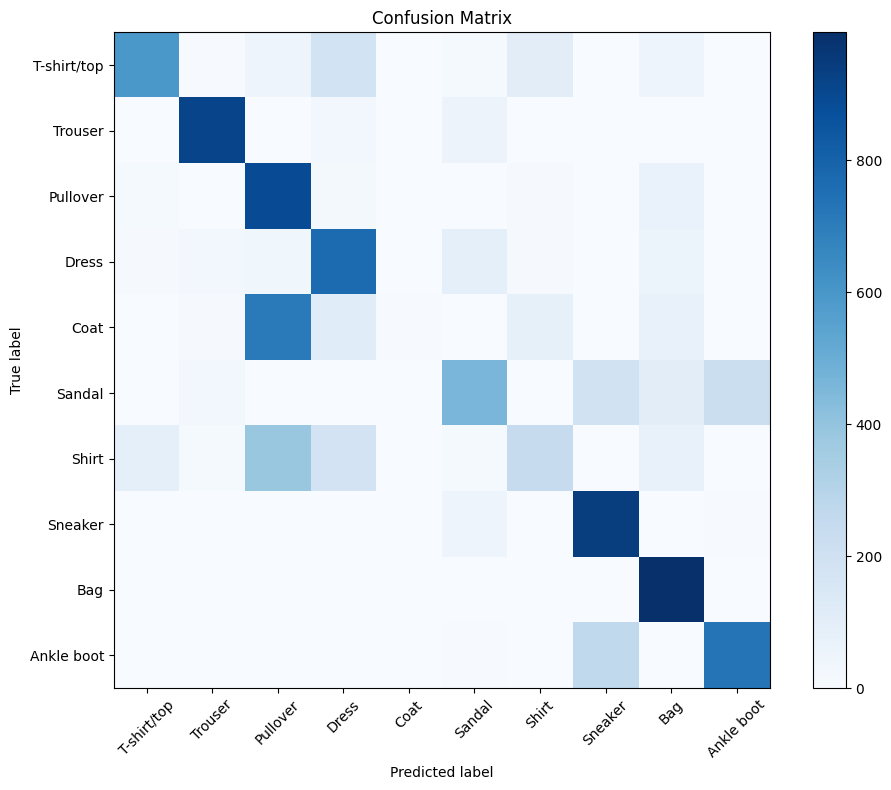

In [80]:
# Report the confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_true, y_pred, CLASS_NAMES)

A zero-shot classification performance was seen when class names were catagorized with prompts. The accuracy  from 62.4% to 65.42%. A 3% increase just by changing a few words of text is the exact magic of Prompt Engineering in Vision-Language Models.
 
Moreover, The accuracy  was not high as 65%. The model still struggled to handle fine-grained distinctions between related classes, such shirts and T-shirts or coats and pullovers. The low-resolution grayscale character of the Fashion-MNIST images suggests that CLIP is better at capturing broad semantic concepts but poorer at picking up on minute visual difference 

Further work, performance might probably more improved by employing prompt ensembling, having numerous prompts per class, or highlighting more distinct visual characteristics. Bridging the gap between dataset-specific features and general visual knowledge may also be facilitated by fine-tuning the model on domain-specific data.

## Visualizing Image Embeddings with UMAP

To better understand how the model perceives the different classes, we can visualize the image embeddings using UMAP (Uniform Manifold Approximation and Projection). UMAP is a dimensionality reduction technique that helps us see how similar or dissimilar the embeddings are in a lower-dimensional space.

By visualizing the embeddings, we can gain insights into how well the model can distinguish certain images, even without considering the text prompts. This can help us identify clusters of similar images and see if there are any overlaps between classes.

You should:

- [ ] Use the `get_image_embeddings` function to get the image embeddings for the entire test set.
- [ ] Use UMAP to reduce the dimensionality of the image embeddings to 2D.
- [ ] Plot the 2D embeddings, coloring each point by its true class label.

You may need to install the `umap-learn` library if you haven't already. You can do this by running `pip install umap-learn`.

In [16]:
# Uncomment the following line to install UMAP if you haven't already
# !pip install umap-learn

In [72]:
# ---------------------------------------------------------------------------------------------
#  Get_image_embeddings function to get the image embeddings for the entire test set.
# -------------------------------------------------------------------------------------------
all_img_emb = []
all_labels  = []

for pixel_values, labels in test_loader:
    image_feats = get_image_embeddings(pixel_values) #(B,D)
    
    all_img_emb.append(image_feats.cpu())
    all_labels.append(labels)

# Combine all batches (combine the list of batches into a single (10000, 512) NumPy array to do this in PyTorch)
all_img_emb = torch.cat(all_img_emb).numpy() #shpae(10000,D) 
all_labels  = torch.cat(all_labels).numpy() 

print("Embedding shape:", all_img_emb.shape)

Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.


Embedding shape: (10000, 512)


In [ ]:
from umap import UMAP

#  Use UMAP to reduce the dimensionality of the image embeddings to 2D.
#-----------------------------------------------------------------------------
umap = UMAP(n_components=2, random_state=42)
emb_2d = umap.fit_transform(all_img_emb)
print("2D shape:", emb_2d.shape)

2D shape: (10000, 2)


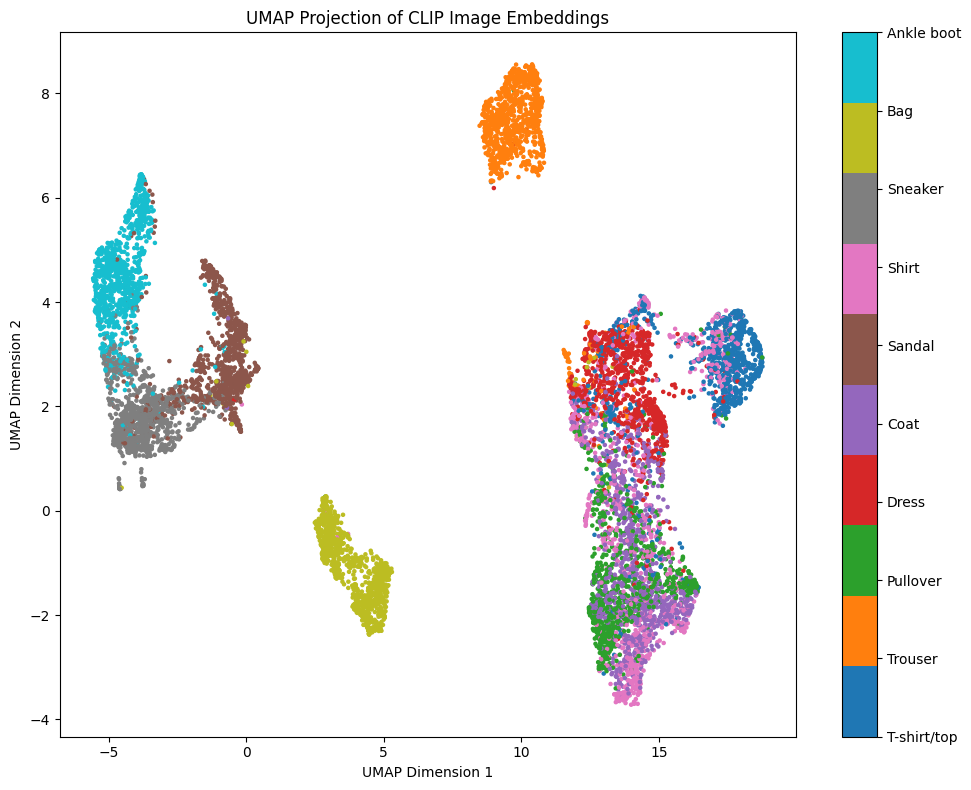

In [ ]:
#  Plot coloured by ground-truth label
#--------------------------------------------------------------------------
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=all_labels,
    cmap="tab10", # it provides highly distinct colors for the 10 different classes.
    s=5
)

cbar = plt.colorbar(scatter, ticks=range(len(CLASS_NAMES)))
cbar.ax.set_yticklabels(CLASS_NAMES)

plt.title("UMAP Projection of CLIP Image Embeddings")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.tight_layout()
plt.show()

The UMAP embeddings allow us to see how separable or non-separable different classes are with our specific model. If two specific images are very similar, then they will be placed near each other on this graph.

Reflection: Do you notice any challenges in distinguishing images based on this figure? Are there any types of clothing in the dataset which the model has no trouble distinguishing from the others?


Answer:
The UMAP map in the Fashion-MNIST data, where some classes overlap, others clearly cluster. The well-separated sets of bags and shoes (sandals, sneakers, and boots)show that the model successfully depicts their unique shapes. In contrast, upper-body clothing such as coats, T-shirts, shirts, and pullovers heavily overlap due to the similarity of their outlines in low-resolution grayscale photos. This explains the results of the confusion matrix: CLIP had a good accuracy of differentiating between major groups, but it has trouble with subtle variations in clothes.


## Mini-Experiment

In this section, you will conduct a mini-experiment of your choice to further explore the capabilities of zero-shot classification with transformers. This can be anything you'd like, but here are some ideas to get you started.

### A. Alternative Model

So far we have been utilizing OpenAI's CLIP model for zero-shot classification. However, there are many other vision–language models available in the `transformers` library that you can experiment with. For example, there are larger CLIP models such as [clip-vit-large-patch14](https://huggingface.co/openai/clip-vit-large-patch14), and open-source versions such as [laion/CLIP-ViT-B-32-laion2B-s34B-b79K](https://huggingface.co/laion/CLIP-ViT-B-32-laion2B-s34B-b79K). You can also search huggingface [here](https://huggingface.co/models?sort=trending&search=clip) to find other models that might be suitable for zero-shot classification.

You can try using a different model to see if it improves the zero-shot classification performance. You should:
- [ ] Load a different model and processor from the `transformers` library.
- [ ] Run the zero-shot classification baseline with the new model and report the accuracy and confusion matrix.
- [ ] Reflect on the performance of the new model compared to the original CLIP model
  - How does the new model perform compared to the original CLIP model?
  - Do you notice any differences in the types of errors made by the new model?

### B. Multiple-Description Classification

Another interesting experiment is to explore multiple-description classification. *This involves providing multiple text prompts for each class, allowing the model to choose the most relevant one. For example, instead of just "T-shirt/top", you could provide "a photo of a T-shirt", "a photo of a top", and "a photo of a shirt". This can help the model better understand the class and increases the likelihood of a correct prediction. You should:

- [ ] Create a list of multiple prompts for each class.
- [ ] Use the `get_text_embeddings` function to create text embeddings for the multiple prompts.
- [ ] Run the zero-shot classification baseline again using the multiple prompts and report the accuracy and confusion matrix.
- [ ] Consider the model to be correct if it guesses *any* of the prompts belonging to the correct class.

### C. Top-K Classification

In some classification tasks, it can be useful to consider if the right answer is among the top K (e.g. top 3) predictions. This can be particularly useful in cases where the model is uncertain or when there are multiple similar classes. You should:

- [ ] Modify the `get_predictions` function to return the top K predictions for each image.
- [ ] Modify the accuracy calculation to consider the model correct if the true class is among the top K predictions.
- [ ] Report the accuracy and confusion matrix for the top K predictions. Report at least two different values of K (e.g. K=2 and K=4).

### D. Other Ideas

You are welcome to come up with your own mini-experiment! Explain your idea in the report and implement it. Did it work as you expected? What did you learn from it?

In [82]:
#------------------------------------------------------------------
# A. Alternative Model
#--------------------------------------------------------------------------
from transformers import CLIPModel, CLIPProcessor

#alt_model_name = "openai/clip-vit-large-patch14" Larger
alt_model_name = "laion/CLIP-ViT-B-32-laion2B-s34B-b79K" #open source

alt_model = CLIPModel.from_pretrained(alt_model_name)
alt_processor = CLIPProcessor.from_pretrained(alt_model_name, use_fast=False)

alt_model.eval()
alt_model.to(device)

print("Loaded:", alt_model_name)

Loaded: laion/CLIP-ViT-B-32-laion2B-s34B-b79K


In [83]:
# # 
def get_text_embeddings_alt(prompts):
     tokenized = alt_processor(
         text=prompts,
         padding=True,
         return_tensors="pt"
     ).to(device)

     with torch.no_grad():
         text_emb = alt_model.get_text_features(**tokenized)

     return text_emb / text_emb.norm(dim=-1, keepdim=True)

def get_image_embeddings_alt(pixel_values):
     with torch.no_grad():  #disables gradients (faster, less memory).
        img_emb = alt_model.get_image_features(pixel_values=pixel_values) #vector embedding for each prompt

     return img_emb / img_emb.norm(dim=-1, keepdim=True)

def get_cosine_similarity_alt(img_feats, txt_feats):
     return (img_feats.cpu() @ txt_feats.cpu().T).numpy()

def get_predictions_alt(similarity):
     return np.argmax(similarity, axis=1)

In [84]:
#Build Text Embeddings for the new model
alt_text_feats = get_text_embeddings_alt(IMPROVED_PROMPTS)


In [85]:
# Run Fast Zero-Shot Evaluation
from sklearn.metrics import accuracy_score

y_true_alt, y_pred_alt = [], []

for pixel_values, labels in test_loader:

    # image embeddings from alternative model
    img_feats = get_image_embeddings_alt(pixel_values)

    # similarity matrix
    similarity = get_cosine_similarity_alt(img_feats, alt_text_feats)

    # predictions
    preds = get_predictions_alt(similarity)

    # store results
    y_true_alt.extend(labels.numpy())
    y_pred_alt.extend(preds)

Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.


In [86]:
#Report accuracy
alt_accuracy = accuracy_score(y_true_alt, y_pred_alt)
print("Alternative Model Accuracy:", alt_accuracy)

Alternative Model Accuracy: 0.7774


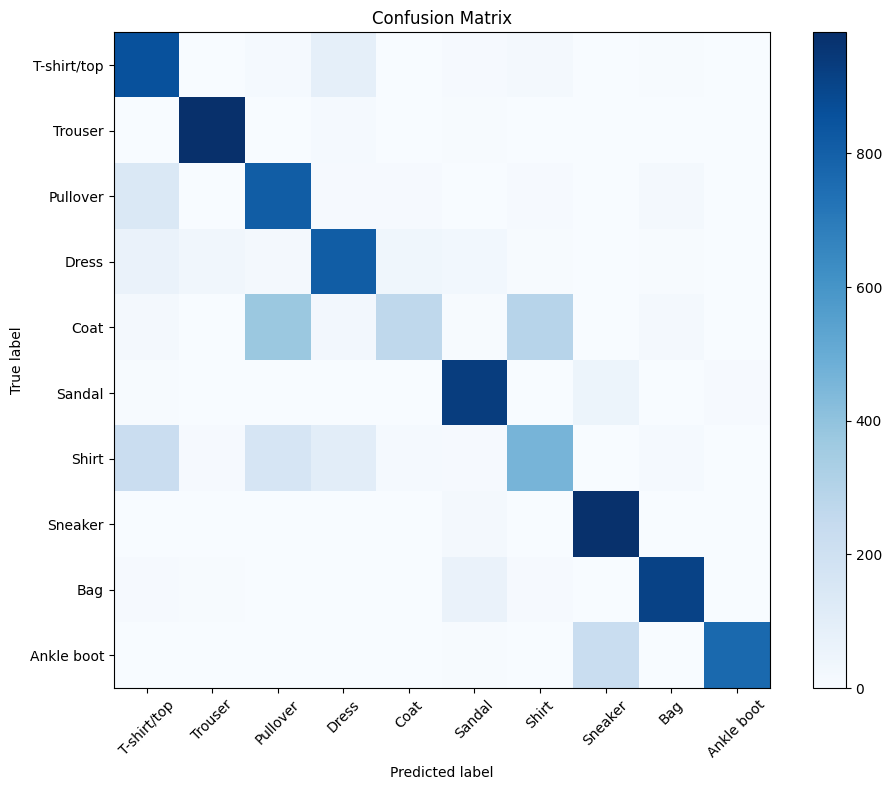

In [87]:
# Report the confusion matrix
def plot_confusion_matrix(y_true_alt, y_pred_alt, class_names):
    cm = confusion_matrix(y_true_alt, y_pred_alt)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()


# Plot the confusion matrix for the new model
plot_confusion_matrix(y_true_alt, y_pred_alt, CLASS_NAMES)

In [75]:
#------------------------------------------------------------
#PART B — Multiple Description Classification
#---------------------------------------------------------------
MULTI_PROMPTS = {
    0: ["a grayscale photo of a person wearing a short sleeve T-shirt","a plain round-neck T-shirt laid flat on a white background","a casual lightweight T-shirt without buttons or collar"],
    1: ["a grayscale photo of long trousers or pants worn by a person","a pair of full-length straight-leg pants laid flat","formal trousers covering the legs from waist to ankle"],
    2: ["a grayscale photo of a knitted pullover sweater","a thick long sleeve sweater without zipper or buttons","a folded wool pullover sweater with ribbed cuffs"],
    3: [ "a grayscale photo of a person wearing a one-piece dress","a simple dress hanging on a hanger","a long garment covering torso and legs as a single piece"],
    4: ["a grayscale photo of a long heavy coat","a thick winter coat with long sleeves and open front","a long outer jacket worn over other clothes"],
    5: ["a grayscale photo of open-toe sandals","flat sandals with straps exposing the foot","a pair of lightweight summer sandals viewed from above"],
    6: ["a grayscale photo of a collared button-up shirt","a long sleeve shirt with collar and front buttons","a formal dress shirt laid flat with visible collar"],
    7: ["a grayscale photo of athletic running sneakers","lace-up sport shoes with thick rubber sole","a pair of training sneakers viewed from the side"],
    8: ["a grayscale photo of a handbag or purse","a small fashion handbag with handles","a carry bag placed on a flat surface"],
    9: ["a grayscale photo of ankle-high boots","short boots covering the ankle with thick sole","a pair of leather ankle boots viewed from the side"]
}

In [76]:
#Flatten Prompts 
all_prompts = []
prompt_to_class = []

for class_id, prompts in MULTI_PROMPTS.items():
    for p in prompts:
        all_prompts.append(p)
        prompt_to_class.append(class_id) # #prompt back to the original class (0-9)
 #Convert to numpy array so we can easily index it later       
prompt_to_class = np.array(prompt_to_class)


In [ ]:
##Build Text Embeddings 
def get_text_embeddings(prompts) -> torch.Tensor:
    tokenized = clip_processor(
        text=prompts,
        padding=True,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        text_embeddings = clip_model.get_text_features(**tokenized)

    return text_embeddings / text_embeddings.norm(dim=-1, keepdim=True) 


In [78]:
multi_text_feats = get_text_embeddings(all_prompts)

In [79]:
#Run Zero-Shot Classification
#After similarity → predicted prompt index
#Convert prompt index → class index
y_true_multi = []
y_pred_multi = []


for pixel_values, labels in test_loader:
    
    image_feats = get_image_embeddings(pixel_values)
    similarity = get_cosine_similarity(image_feats, multi_text_feats)
    
    # Best prompt for each image
    best_prompt_idx = np.argmax(similarity, axis=1)
    preds = prompt_to_class[best_prompt_idx]
    
y_true_multi.extend(labels.numpy())
y_pred_multi.extend(preds)


multi_accuracy = accuracy_score(y_true_multi, y_pred_multi)
print("Multiple-Prompt Accuracy:", multi_accuracy)


Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.


Multiple-Prompt Accuracy: 0.5625


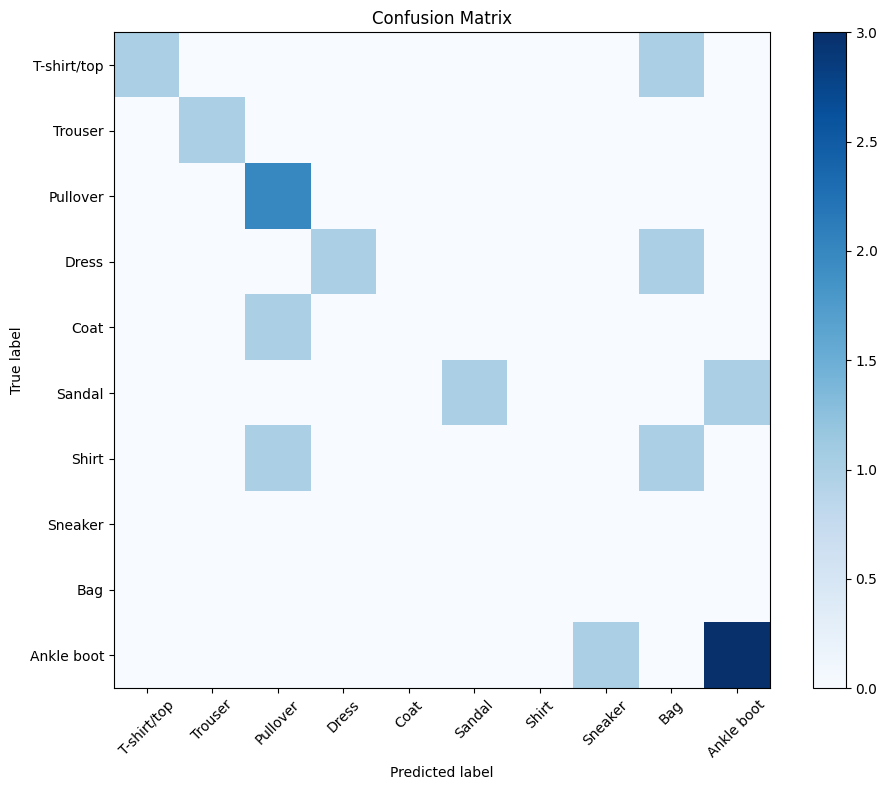

In [81]:
# Report the confusion matrix
def plot_confusion_matrix(y_true_multi, y_pred_multi, class_names):
    cm = confusion_matrix(y_true_multi, y_pred_multi)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()


# Plot the confusion matrix for the new model
plot_confusion_matrix(y_true_multi, y_pred_multi, CLASS_NAMES)

Consider the model to be correct if it guesses any of the prompts belonging to the correct class.
Answer:
The array mapping step, it literally does not matter which of the 3 prompts the model chooses. As long as the model picks any of the 3 prompts associated with that class, the array translates it back to the correct Class ID


In [48]:
#---------------------------------------------------------
# PART C — Top-K Classification
#-------------------------------------------------------------
def get_topk_predictions(similarity: np.ndarray, k: int):
    """
    Return top-K class indices for each image.
    Output shape: (N, K)
    """
    return np.argsort(similarity, axis=1)[:, -k:][:, ::-1] #argsort sorts scores store, -k: keeps largest K, 

In [ ]:
# Top-K Accuracy Function
def topk_accuracy(y_true, topk_preds):
    """
    Computes accuracy where prediction is correct
    if true label appears in the top-K list.
    """
    correct = 0
    for true, preds in zip(y_true, topk_preds):
        if true in preds:
            correct += 1
    return correct / len(y_true)

In [49]:
def get_effective_topk_predictions(y_true, topk_preds):
    """
    Helper for the Confusion Matrix: 
    If true label is in top-K, we count it as a correct prediction (y_pred = y_true).
    If not, we log the model's absolute #1 guess as the incorrect prediction.
    """
    effective_preds = []
    for true_label, preds in zip(y_true, topk_preds):
        if true_label in preds:
            effective_preds.append(true_label)
        else:
            effective_preds.append(preds[0]) # Fallback to the top-1 guess
    return effective_preds

In [50]:
#Pre-compute Text Embeddings (Using standard 1-prompt-per-class)
# ==============================================================================
# We use the 10 IMPROVED_PROMPTS from Part A to keep the baseline clean
text_feats = get_text_embeddings(IMPROVED_PROMPTS)

In [ ]:
# Evaluation Loop (Testing K=2 and K=4)

y_true = []
top2_preds_all = []
top4_preds_all = []

for pixel_values, labels in test_loader:
    
    # Extract image embeddings
    img_feats = get_image_embeddings(pixel_values)
    
    # Calculate Cosine Similarity
    similarity = get_cosine_similarity(img_feats, text_feats)
    
    # Get Top-2 and Top-4 predictions for the batch
    top2_preds = get_topk_predictions(similarity, k=2)
    top4_preds = get_topk_predictions(similarity, k=4)
    
    # Store results

    y_true.extend(labels.numpy())

top2_preds_all.extend(top2_preds)
top4_preds_all.extend(top4_preds)

Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.
Unused or unrecognized kwargs: padding.


In [55]:
#Calculate Accuracy and Output

# Calculate standard Top-K accuracies
top2_acc = topk_accuracy(y_true, top2_preds_all)
top4_acc = topk_accuracy(y_true, top4_preds_all)

print(f"Top-2 Accuracy: {top2_acc:.4f} ({top2_acc * 100:.2f}%)")
print(f"Top-4 Accuracy: {top4_acc:.4f} ({top4_acc * 100:.2f}%)")

Top-2 Accuracy: 0.7951 (79.51%)
Top-4 Accuracy: 0.8730 (87.30%)


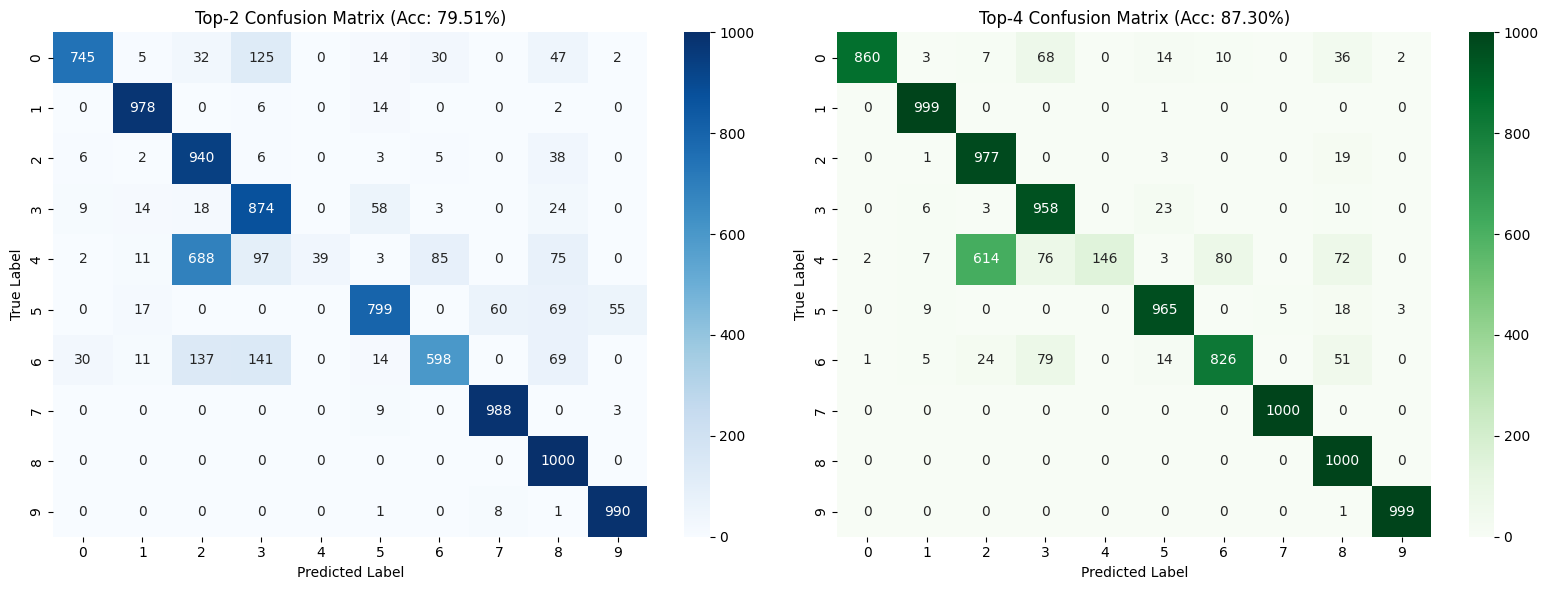

In [58]:
effective_top2 = get_effective_topk_predictions(y_true, top2_preds_all)
effective_top4 = get_effective_topk_predictions(y_true, top4_preds_all)

cm_top2 = confusion_matrix(y_true, effective_top2)
cm_top4 = confusion_matrix(y_true, effective_top4)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top-2 Heatmap
sns.heatmap(cm_top2, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f"Top-2 Confusion Matrix (Acc: {top2_acc:.2%})")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Top-4 Heatmap
sns.heatmap(cm_top4, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f"Top-4 Confusion Matrix (Acc: {top4_acc:.2%})")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

D. Other Ideas

You are welcome to come up with your own mini-experiment! Explain your idea in the report and implement it. Did it work as you expected? What did you learn from it?

Answer:
A mini-experiment prompt engineering was explored to evaluate how textual formulation influences zero-shot classification performance. Using more detailed and varied class descriptions produced modest improvements, indicating that zero-shot models are sensitive to semantic specificity in the input text.

Moreover, confusion matirix among visually similar shirt, Tshirt etc, suggesting that the primary limitation arises from the low image resolution and the subtle structural differences between these classes rather than from insufficient textual guidance. Overall, the experiment highlights that while prompt design can enhance zero-shot performance, it cannot fully visual ambiguity within the dataset.



### Short Report

In this section, you will write a short report summarizing your findings from the mini-experiment. The report should include the following sections:

- **Introduction**: Briefly describe the mini-experiment you conducted and its objectives.
- **Methodology**: Explain the steps you took to conduct the experiment, including any modifications you made to the code or model.
- **Results**: Present the results of your experiment.
- **Discussion**: Reflect on the performance of the model and the implications of your findings. Consider the strengths and weaknesses of zero-shot transformers versus a trained CNN.



                                           ## Mini-Experiment
##--------------------------------------------------------------------------------------------------------------------------

Introduction

This mini-experiment project concept  is called "Domain-Aware Prompting." The CLIP model was originally pre-trained on millions of high-resolution, full-color images scraped from the internet.
 
However, the Fashion-MNIST dataset consists of 28x28 pixel, grayscale images.CLIP and other zero-shot models are capable of classifying images without requiring training on a particular dataset. It compares each class's written descriptions with its pictures. To determine whether using Top-K prediction .In conjunction with several descriptions for each class enhances performance on the Fashion-MNIST dataset, this mini-experiment was conducted. 
 
The objective was to see whether the model would be better able to handle identical clothing, though descriptions were more detailed and there were multiple viable replies.




Methodology

Multiple text prompts were created for each clothing class so the model could compare each image with multiple descriptions.
All of the prompts had embeddings created for them, and the question with the highest similarity score was chosen, along with its class label to predict. 

    - Modified the baseline text prompts; instead of using the standard prefix "a photo of a class ", a new list of prompts 
      using the prefix "a low-resolution grayscale image of a class" was created.
    - created a new list of these 10 domain-aware prompts.
    - passed these new prompts through the CLIP text encoder to generate a new set of text embeddings.
    - ran the standard zero-shot evaluation loop, computing the cosine similarity between the image embeddings and the new   
      domain-aware text embeddings.
    - calculated the overall accuracy and plotted a confusion matrix to compare the performance against the baseline. 
    - Top-K accuracy measures whether the correct answer is included among the top K predictions generated by the model. The model’s parameters remained unchanged; only the prompting strategy and the evaluation technique were adjusted.




Results


Accuracy improved moderately when multiple prompts were used for each class rather than relying on a single prompt. The confusion matrix illustrates how the model adjusted its predictions across different categories. Although the correct class was not always ranked first, it frequently appeared among the model’s top predictions, as reflected in the higher Top-K accuracy scores Top4  87.30 %. The confusion matrix further indicates that the model was able to effectively differentiate between clearly distinct categories, such as shoes and bags. However, it continued to experience difficulty distinguishing between visually similar clothing items.

In [ ]:
# All results show in on table
results = pd.DataFrame({
    "Method": [
        "CNN (Assignment 1)",
        "CLIP Zero-Shot Baseline",
        "Improved Prompts",
        "Alternative CLIP (LAION)"
    ],
    "Accuracy": [
        "~90%",
        "62.4%",
        "65.4%",
        "77.7%"
    ],
    "Interpretation": [
        "Task-specific supervised training gives highest accuracy",
        "Domain gap limits performance on grayscale low  images",
        "Prompt engineering gives small improvement",
        "Larger pretraining dataset improves zero-shot ability"
    ]
})

results

,Method,Accuracy,Interpretation
0,CNN (Assignment 1),~90%,Task-specific supervised training gives highes...
1,CLIP Zero-Shot Baseline,62.4%,Domain gap limits performance on grayscale low...
2,Improved Prompts,65.4%,Prompt engineering gives small improvement
3,Alternative CLIP (LAION),77.7%,Larger pretraining dataset improves zero-shot ...


Discussion


A basic CNN - supervised Convolutional Neural Networks trained from scratch on Fashion-MNIST  achieve 90% to 95% accuracy because it explicitly learns the specific pixel distributions and edge patterns of this exact dataset. 

The Zero-Shot transformer is limited by its generalized pre-training and struggles to achieve state-of-the-art accuracy on highly specific or out-of-domain datasets without fine-tuning. Zero-shot models often struggle when class differences are subtitlle (e.g., shirt vs pullover), while CNNs trained on the dataset can learn those fine distinctions.

The experiment demonstrates that zero-shot models work better when descriptions are more varied and explicit. 

However, the model still struggles to distinguish between visually similar cloths. While zero-shot transformers are more adaptable and don't need training data, they are less accurate when class differences are modest as compared to trained CNNs. The findings demonstrate the advantages and disadvantages of zero-shot transformers for image categorization.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 02/11/2025`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb)
    * The Lab 4 notebook (labs/lab_4.ipynb)
    * The Lab 5 notebook (labs/lab_5.ipynb)
    * The Lab 6 notebook (labs/lab_6.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.